Now categorized results into four lens morphology groups: 

1- Einstein Rings 

2- Double Source Plane Lenses

3- Edge-on Lenses 

4- Group/Cluster-scale Lenses

In [ ]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
import shutil

In [2]:
source_root = "raw_data/Euclid_Lens_Dataset"      
target_root = "data" 

os.makedirs(target_root, exist_ok=True)

count = 0

for folder in os.listdir(source_root):
    folder_path = os.path.join(source_root, folder)

    jpeg_folder = os.path.join(folder_path, "jpeg")

    if os.path.exists(jpeg_folder):
        for file in os.listdir(jpeg_folder):
            if file.endswith(".jpg") or file.endswith(".jpeg"):
                src = os.path.join(jpeg_folder, file)
                dst = os.path.join(target_root, f"{folder}_{file}")

                shutil.copy(src, dst)
                count += 1

print("Total images copied:", count)

Total images copied: 2660


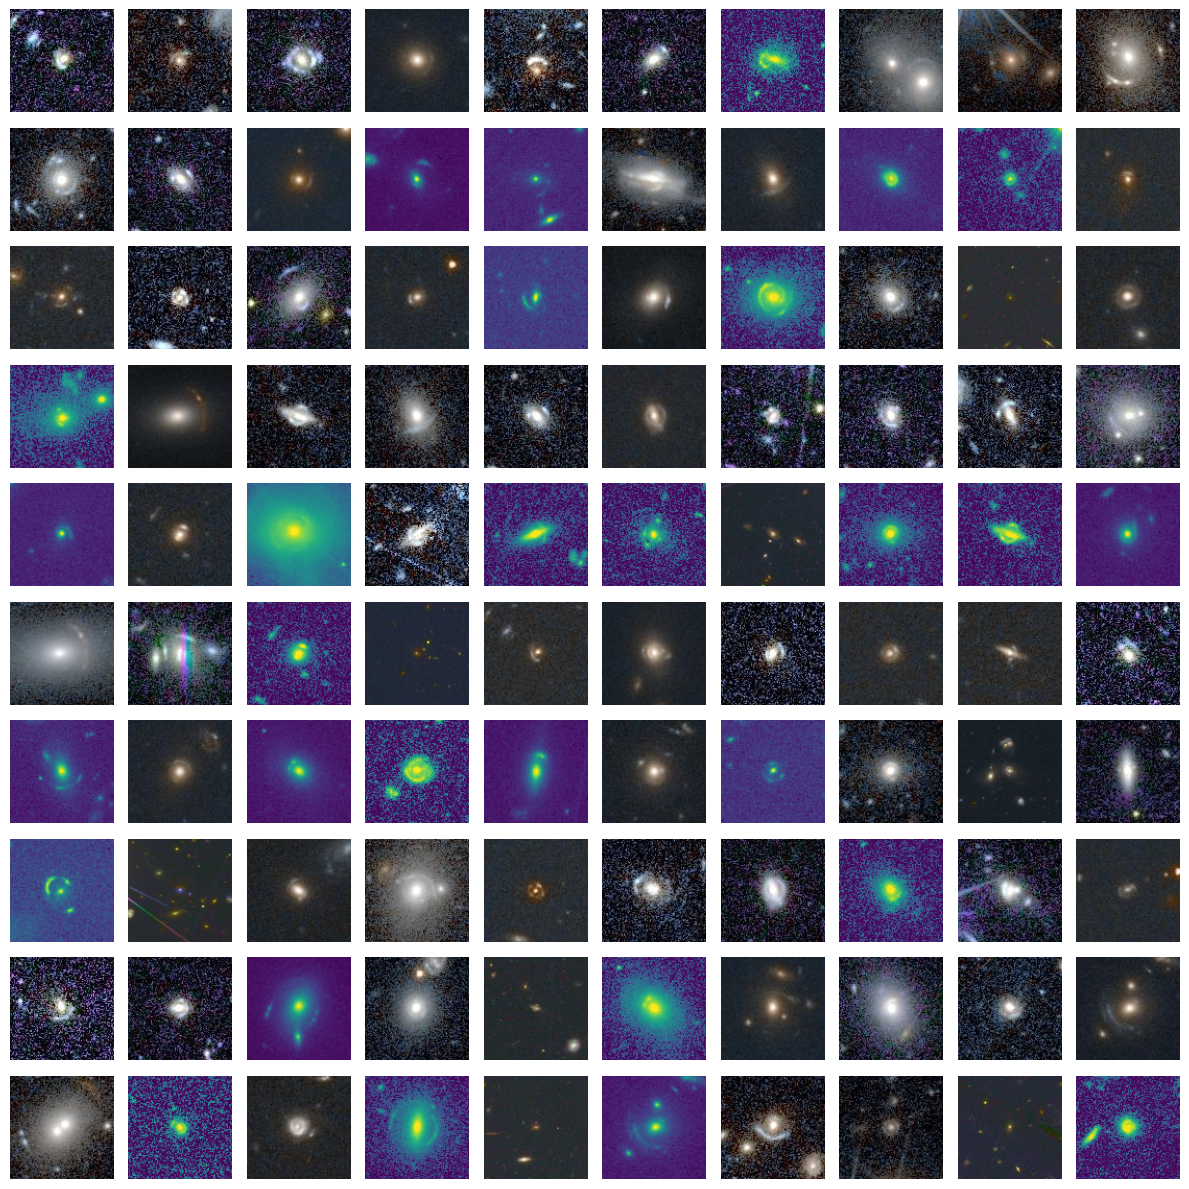

In [ ]:
folder = "data"

images = os.listdir(folder)
sample = random.sample(images, 100)

plt.figure(figsize=(12,12))

for i, img_name in enumerate(sample):
    img = Image.open(os.path.join(folder, img_name))

    plt.subplot(10,10,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [5]:
# %pip install torch torchvision pillow matplotlib scikit-learn umap-learn pandas

In [ ]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torchvision.models as models
import torchvision.transforms as transforms

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import umap.umap_ as umap

In [1]:
image_folder = "data"

image_size = 224
n_clusters = 8   # start with 6, 8, or 10 and compare
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

NameError: name 'torch' is not defined

In [3]:
weights = models.ResNet50_Weights.DEFAULT   
model = models.resnet50(weights=weights)    

# remove final classification layer
feature_extractor = torch.nn.Sequential(*list(model.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\nguye/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:07<00:00, 14.3MB/s]


Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)


In [4]:
transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [10]:
print(os.listdir())

['01_extract_images.ipynb']


In [12]:
image_paths = []
features = []

valid_exts = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

for fname in os.listdir(image_folder):
    if not fname.lower().endswith(valid_exts):
        continue

    path = os.path.join(image_folder, fname)

    try:
        img = Image.open(path).convert("RGB")
        x = transform(img).unsqueeze(0).to(device)

        with torch.no_grad():
            feat = feature_extractor(x)
            feat = feat.view(-1).cpu().numpy()

        image_paths.append(path)
        features.append(feat)

    except Exception as e:
        print(f"Skipping {fname}: {e}")

features = np.array(features)

print("Number of images processed:", len(image_paths))
print("Feature shape:", features.shape)

FileNotFoundError: [WinError 3] The system cannot find the path specified: './data'